In [1]:
import torch
import time
import matplotlib.pyplot as plt
import cv2
import numpy as np
import logging
import os
import torchvision.transforms as T

from pathlib import Path
from PIL import Image
from insightface.app import FaceAnalysis
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from ip_adapter.custom_pipelines import StableDiffusionXLCustomPipeline, StableDiffusionXLCustomPipelineMorph
from ip_adapter.ip_adapter_faceid import IPAdapterFaceID, IPAdapterFaceIDXL

/home/chettaou/anaconda3/envs/ipadapt/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chettaou/anaconda3/envs/ipadapt/lib/python3.9/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/chettaou/anaconda3/envs/ipadapt/lib/python3.9/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/chettaou/anaconda3/envs/ipadapt/lib/python3.9/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. 

In [2]:
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

def clear_cache(img):
    del img
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(224, 224))
rec_model = app.models["recognition"]

base_model_path = "SG161222/RealVisXL_V3.0"
vae_model_path = "stabilityai/sd-vae-ft-mse"
ip_ckpt ="./ip-adapter-faceid_sdxl.bin" # TODO: Adapt path
device = "cuda"

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)

pipe = StableDiffusionXLCustomPipelineMorph.from_pretrained(
    base_model_path,
    torch_dtype=torch.float16,
    scheduler=noise_scheduler,
    add_watermarker=False,
)

vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float16)

# load ip-adapter
ip_model = IPAdapterFaceIDXL(pipe, ip_ckpt, device)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/chettaou/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUE

Loading pipeline components...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  4.21it/s]


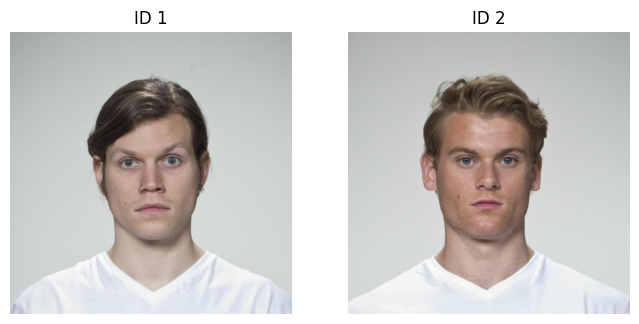

Morph cross attention: alpha=0.5


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:04<00:00,  6.03it/s]


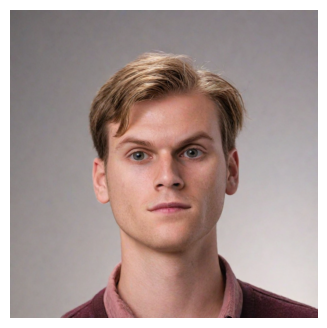

Morph_average: alpha=0.5


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:03<00:00,  9.07it/s]


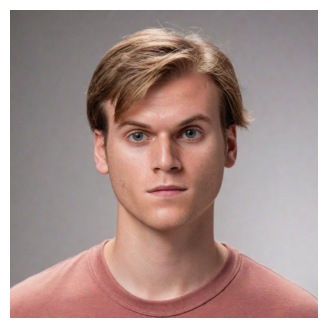

Morph + image inversion: alpha=0.5


/home/chettaou/anaconda3/envs/ipadapt/lib/python3.9/site-packages/diffusers/configuration_utils.py:135: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDIMInverseScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDIMInverseScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:05<00:00,  5.77it/s]


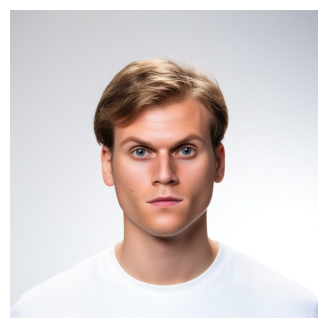

In [4]:
path_id1 = "01.jpg" # TODO: Adapt path
path_id2 = "02.jpg" # TODO: Adapt path

prompt = "headshot, high quality, best quality"
negative_prompt = "monochrome, lowres, bad anatomy, worst quality, low quality, blurry"
guidance_scale = 2
w = 1024
h = 1024
show_id1 = False
show_id2 = False
alpha = 0.5

image_1 = cv2.imread(path_id1)
image_1_pil = Image.open(path_id1).convert("RGB")
image_2 = cv2.imread(path_id2)
image_2_pil = Image.open(path_id2).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(8, 6))
axes[0].imshow(image_1_pil)
axes[0].axis('off')
axes[0].set_title("ID 1")
axes[1].imshow(image_2_pil)
axes[1].axis('off')  # hide axes
axes[1].set_title("ID 2")
plt.show()

transform = T.Compose([
    T.Resize((h,w), interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop((h, w)),
    T.ToTensor(),                 # [0,1]
    T.Normalize([0.5]*3, [0.5]*3) # [-1,1]
])
image_1_pil.resize((h, w))
image_2_pil.resize((h, w))
image_1_pil = transform(image_1_pil).unsqueeze(0)  # [1,3,H,W]
image_2_pil = transform(image_2_pil).unsqueeze(0)
image_batch = torch.cat([image_1_pil, image_2_pil], dim=0)  # [2,3,H,W]

####################################
# ID_1
with torch.no_grad():
    faces = app.get(image_1)
    assert len(faces) > 0
    faceid_embeds_1 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)    
 
    if show_id1:
        images = ip_model.generate(
            prompt=prompt, negative_prompt=negative_prompt, faceid_embeds=faceid_embeds_1,
            num_samples=2, width=w, height=h, num_inference_steps=30, guidance_scale=guidance_scale, seed=2023
        )
    
        image_1_pil = image_1_pil.resize((1024, 1024))
        images.insert(0, image_1_pil)
        plt.figure(figsize=(8, 4))
        plt.imshow(image_grid(images, 1, 3))
        plt.axis('off')  # hide axes
        plt.show()
        clear_cache(images)

####################################
# ID_2
with torch.no_grad():
    faces = app.get(image_2)
    assert len(faces) > 0
    faceid_embeds_2 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)    

    if show_id2:
        images = ip_model.generate(
            prompt=prompt, negative_prompt=negative_prompt, faceid_embeds=faceid_embeds_2,
            num_samples=2, width=w, height=h, num_inference_steps=30, guidance_scale=guidance_scale, seed=2023
        )
        
        image_2_pil = image_2_pil.resize((1024, 1024))
        images.insert(0, image_2_pil)
        plt.figure(figsize=(8, 4))
        plt.imshow(image_grid(images, 1, 3))
        plt.axis('off')  # hide axes
        plt.show()
        clear_cache(images)

####################################
print(f"Morph cross attention: alpha={alpha}")
with torch.no_grad():
    images = ip_model.morph(
        prompt=prompt, negative_prompt=negative_prompt, faceid_embeds_1=faceid_embeds_1, faceid_embeds_2=faceid_embeds_2,  
        num_samples=1, width=w, height=h, num_inference_steps=30, guidance_scale=guidance_scale, seed=2023, 
        morph_sph_inter=False, scale=alpha
    )

plt.figure(figsize=(8, 4))
plt.imshow(image_grid(images, 1, 1))
plt.axis('off')  # hide axes
plt.show()
clear_cache(images)

####################################
print(f"Morph_average: alpha={alpha}")
with torch.no_grad():
    images = ip_model.morph_avg(
        prompt=prompt, negative_prompt=negative_prompt, faceid_embeds_1=faceid_embeds_1, faceid_embeds_2=faceid_embeds_2,  
        num_samples=1, width=w, height=h, num_inference_steps=30, guidance_scale=guidance_scale, seed=2023, 
        morph_sph_inter=False, alpha=alpha, image_inversion=False, start_image=image_batch, start_ratio=0.0
    )

plt.figure(figsize=(8, 4))
plt.imshow(image_grid(images, 1, 1))
plt.axis('off')  # hide axes
plt.show()
clear_cache(images)

####################################
#print("Morph + TE-> IE")
if False:
    with torch.no_grad():
        images = ip_model.morph_ie(
            prompt=prompt, negative_prompt=negative_prompt, faceid_embeds_1=faceid_embeds_1, faceid_embeds_2=faceid_embeds_2,  
            num_samples=2, width=w, height=h, num_inference_steps=30, guidance_scale=guidance_scale, seed=2023, 
            morph_sph_inter=False,
        )
    
    plt.figure(figsize=(8, 4))
    plt.imshow(image_grid(images, 1, 2))
    plt.axis('off')  # hide axes
    plt.show()
    clear_cache(images)

print(f"Morph + image inversion: alpha={alpha}")
with torch.no_grad():
    images = ip_model.morph_inv(
        prompt=prompt, negative_prompt=negative_prompt, faceid_embeds_1=faceid_embeds_1, faceid_embeds_2=faceid_embeds_2,  
        num_samples=1, width=w, height=h, num_inference_steps=30, guidance_scale=guidance_scale, seed=2023, 
        morph_sph_inter=False, image_inversion=True, start_image=image_batch, start_ratio=0.0, scale=alpha
    )

plt.figure(figsize=(8, 4))
plt.imshow(image_grid(images, 1, 1))
plt.axis('off')  # hide axes
plt.show()
clear_cache(images)